In [32]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [33]:
## 2. Load Dataset
df=pd.read_csv("Manufacturing_data.csv")
df.head()

,event_id,event_ts,plant,line,shift,machine_id,operator_id,machine_age_yrs,material_grade,temp_c,...,defect_type,defect_severity_0to3,decision_rework,rework_time_min,final_pass,scrap,total_cycle_time_min,energy_kwh,cost_usd,warranty_claim_90d
0,M200000,2025-08-27 17:15:31,plant_1,line_A,day,MC104,OP1009,1.55,grade_B,5.9,...,none,0,0,0.0,1,0,33.7,1.413,25.53,0
1,M200001,2025-11-09 16:28:50,plant_1,line_A,swing,MC158,OP1419,1.98,grade_B,11.2,...,none,0,1,0.0,1,0,26.1,1.313,19.81,0
2,M200002,2025-12-20 06:18:01,plant_1,line_D,night,MC144,OP1042,0.20,grade_B,17.8,...,none,0,0,0.0,1,0,35.3,1.512,31.75,0
3,M200003,2025-12-06 12:38:46,plant_2,line_B,night,MC108,OP1013,0.90,grade_B,12.9,...,none,0,0,0.0,1,0,28.5,1.201,21.59,0
4,M200004,2025-07-31 07:28:14,plant_1,line_C,day,MC113,OP1312,1.92,grade_A,11.7,...,none,0,0,0.0,1,0,28.2,1.372,21.40,0


In [34]:
## 3.  Explore Dataset
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event_id                10000 non-null  object 
 1   event_ts                10000 non-null  object 
 2   plant                   10000 non-null  object 
 3   line                    10000 non-null  object 
 4   shift                   10000 non-null  object 
 5   machine_id              10000 non-null  object 
 6   operator_id             10000 non-null  object 
 7   machine_age_yrs         10000 non-null  float64
 8   material_grade          10000 non-null  object 
 9   temp_c                  10000 non-null  float64
 10  humidity_pct            10000 non-null  float64
 11  process_speed_units_hr  10000 non-null  float64
 12  inspection_method       10000 non-null  object 
 13  defect_type             10000 non-null  object 
 14  defect_severity_0to3    10000 non-null 

,machine_age_yrs,temp_c,humidity_pct,process_speed_units_hr,defect_severity_0to3,decision_rework,rework_time_min,final_pass,scrap,total_cycle_time_min,energy_kwh,cost_usd,warranty_claim_90d
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.037194,12.631810,52.139380,121.867890,0.289400,0.243400,4.850600,0.876100,0.024800,34.519240,1.421557,29.044780,0.012500
std,2.931235,4.359551,12.576449,25.059713,0.725052,0.429156,10.967959,0.329484,0.155523,12.097269,0.214006,17.226903,0.111108
min,0.200000,5.000000,18.200000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.400000,0.902000,10.510000,0.000000
25%,3.970000,9.300000,41.900000,104.900000,0.000000,0.000000,0.000000,1.000000,0.000000,27.300000,1.283000,21.630000,0.000000
50%,6.070000,12.200000,52.800000,121.500000,0.000000,0.000000,0.000000,1.000000,0.000000,31.300000,1.385000,24.850000,0.000000
75%,8.040000,15.800000,62.300000,139.100000,0.000000,0.000000,0.000000,1.000000,0.000000,36.600000,1.508000,29.150000,0.000000
max,17.980000,28.100000,86.700000,190.000000,3.000000,1.000000,60.000000,1.000000,1.000000,97.600000,2.486000,164.310000,1.000000


In [35]:
## 4. Data Cleaning
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

In [36]:
## 4. Data Validation
numeric_cols = [
    "machine_age_yrs",
    "temp_c",
    "humidity_pct",
    "process_speed_units_hr",
    "rework_time_min",
    "total_cycle_time_min",
    "energy_kwh",
    "cost_usd"
]

df[numeric_cols].describe()
(df[numeric_cols]<0).sum()


,0
machine_age_yrs,0
temp_c,0
humidity_pct,0
process_speed_units_hr,0
rework_time_min,0
total_cycle_time_min,0
energy_kwh,0
cost_usd,0


In [37]:
df["plant"].unique()
df["shift"].unique()
df['material_grade'].unique()
df['inspection_method'].unique()

array(['manual', 'vision', 'sensor'], dtype=object)

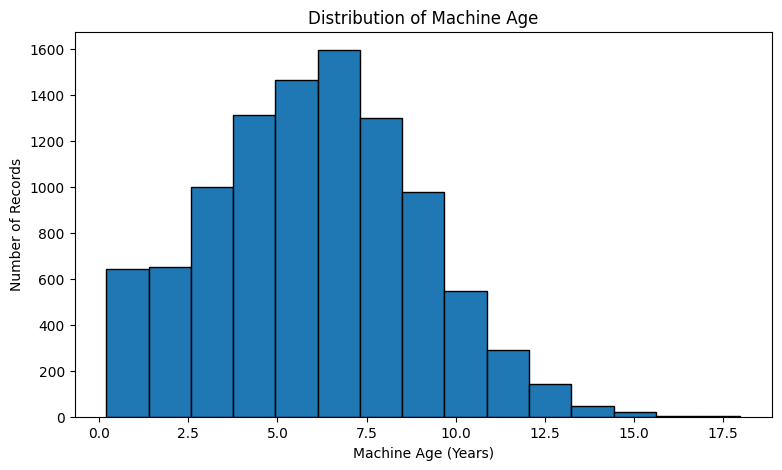

In [38]:
## EDA Plots
plt.figure(figsize=(9,5))

plt.hist(df["machine_age_yrs"], bins=15, edgecolor="black")

plt.title("Distribution of Machine Age")
plt.xlabel("Machine Age (Years)")
plt.ylabel("Number of Records")

plt.show()

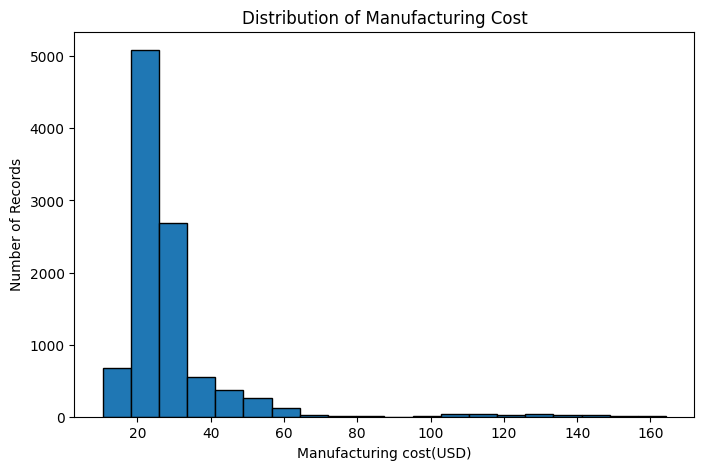

In [39]:
plt.figure(figsize=(8,5))

plt.hist(df['cost_usd'],bins=20,edgecolor="Black")

plt.title("Distribution of Manufacturing Cost")
plt.xlabel("Manufacturing cost(USD)")
plt.ylabel("Number of Records")
plt.show()


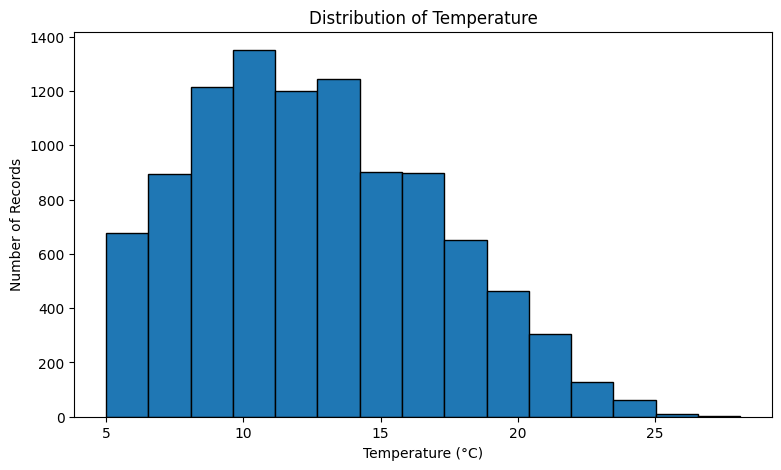

In [40]:
# Temperature Distribution
plt.figure(figsize=(9,5))
plt.hist(df["temp_c"], bins=15, edgecolor="black")
plt.title("Distribution of Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Number of Records")
plt.show()

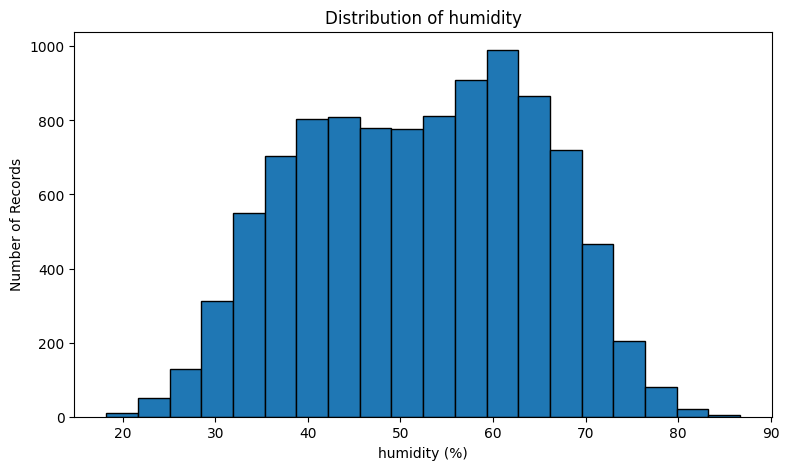

In [41]:
plt.figure(figsize=(9,5))
plt.hist(df['humidity_pct'],bins=20, edgecolor= "black")
plt.title("Distribution of humidity")
plt.xlabel("humidity (%)")
plt.ylabel("Number of Records")
plt.show()

# Conclusion

The dataset was successfully validated by checking missing values, duplicates, categorical values, and numerical ranges.

Exploratory Data Analysis showed that machine age, manufacturing cost, temperature, and humidity follow realistic distributions without major anomalies.

The cleaned and validated dataset was then used for SQL-based business analysis and Power BI dashboard development.